In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM,SimpleRNN, Dense, Attention, TimeDistributed, Input, MultiHeadAttention, LayerNormalization

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Plant disease/yield_df.csv')

In [3]:
X = df[['pesticides_tonnes','Item','Year','average_rain_fall_mm_per_year','avg_temp']]
y = df['hg/ha_yield']

In [4]:
X

,pesticides_tonnes,Item,Year,average_rain_fall_mm_per_year,avg_temp
0,121.00,Maize,1990,1485,16.37
1,121.00,Potatoes,1990,1485,16.37
2,121.00,"Rice, paddy",1990,1485,16.37
3,121.00,Sorghum,1990,1485,16.37
4,121.00,Soybeans,1990,1485,16.37
...,...,...,...,...,...
28237,2550.07,"Rice, paddy",2013,657,19.76
28238,2550.07,Sorghum,2013,657,19.76
28239,2550.07,Soybeans,2013,657,19.76
28240,2550.07,Sweet potatoes,2013,657,19.76


In [5]:
X = X.drop('Item', axis=1)

In [6]:
X.shape

(28242, 4)

In [7]:
y.shape

(28242,)

In [8]:
y

,hg/ha_yield
0,36613
1,66667
2,23333
3,12500
4,7000
...,...
28237,22581
28238,3066
28239,13142
28240,22222


In [9]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [10]:
encoded_df = encoder.fit_transform(df[['Item']])
encoded_df = pd.DataFrame(encoded_df, columns=encoder.get_feature_names_out(['Item']))
df = pd.concat([df, encoded_df], axis=1)

In [11]:
X = pd.concat([X, encoded_df], axis=1)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
model = LinearRegression()

In [14]:
model.fit(X_train, y_train)

LinearRegression()

In [16]:
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_normalized = X_scaler.fit_transform(X)
y_normalized = y_scaler.fit_transform(y.values.reshape(-1, 1))

In [17]:
# Make predictions
y_pred = model.predict(X_test)

# Reshape predictions to match the shape of y_test before inverse transform
y_pred = y_pred.reshape(-1, 1)  # Reshape to a column vector

# Inverse transform predictions
y_pred_original = y_scaler.inverse_transform(y_pred)
y_test_original = y_scaler.inverse_transform(y_test.values.reshape(-1, 1)) # Reshape y_test as well

In [18]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [19]:
# Calculate metrics
mse = mean_squared_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)

In [20]:
print("Mean Squared Error:", mse)
print("R-squared Score:", r2)

Mean Squared Error: 6.351294726363318e+20
R-squared Score: 0.651661460872279


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

The accuracy of the Random Forest Model Train is 99.75
The accuracy of the  Random Forest Model Test is 98.36


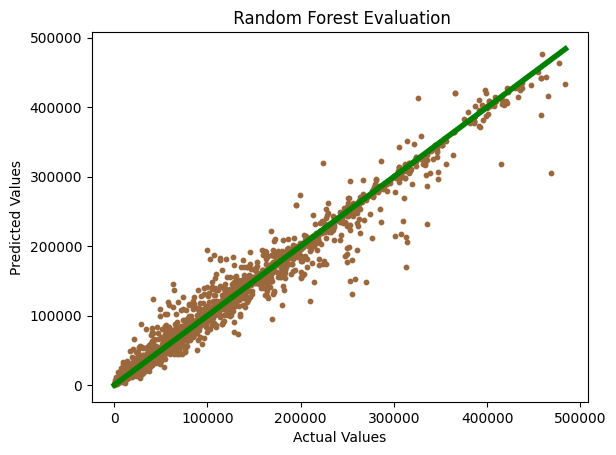

In [22]:
results = []

models = [
    ('Random Forest', RandomForestRegressor(random_state=42))
          ]

for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = model.score(X_test, y_test)
    MSE = mean_squared_error(y_test, y_pred)
    R2_score = r2_score(y_test, y_pred)
    results.append((name, accuracy, MSE, R2_score))
    acc = (model.score(X_train , y_train)*100)
    print(f'The accuracy of the {name} Model Train is {acc:.2f}')
    acc =(model.score(X_test , y_test)*100)
    print(f'The accuracy of the  {name} Model Test is {acc:.2f}')
    plt.scatter(y_test, y_pred,s=10,color='#9B673C')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f' {name} Evaluation')
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='green', linewidth = 4)
    plt.show()

In [24]:
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = model.score(X_test, y_test)
    results.append((name,accuracy))

In [25]:
# Reshape data for LSTM (samples, timesteps, features)
def create_sequences(X, y, time_steps=3):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

# Create sequences
time_steps = 3
X_seq, y_seq = create_sequences(X_normalized, y_normalized, time_steps)

# Split into train and test sets
train_size = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:train_size], X_seq[train_size:]
y_train, y_test = y_seq[:train_size], y_seq[train_size:]


In [26]:
def create_lstm_attention_model(input_shape):
    # Define input layer
    inputs = Input(shape=input_shape)

    # LSTM layers
    x = LSTM(64, return_sequences=True)(inputs)
    x = LSTM(32, return_sequences=True)(x)

    # Temporal-spatial attention using the Functional API
    # Explicitly pass the output of the LSTM as query, key, and value
    attention_output = MultiHeadAttention(num_heads=2, key_dim=32, value_dim=32)(x, x, x)
    x = LayerNormalization()(attention_output)

    # Output layers
    x = TimeDistributed(Dense(16, activation='relu'))(x)
    outputs = Dense(1)(x)

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Create and train model
model = create_lstm_attention_model((time_steps, X.shape[1]))
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
565/565 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0245 - mae: 0.1140 - val_loss: 0.0195 - val_mae: 0.0996
Epoch 2/50
565/565 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.0195 - mae: 0.0959 - val_loss: 0.0215 - val_mae: 0.1070
Epoch 3/50
565/565 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0171 - mae: 0.0876 - val_loss: 0.0254 - val_mae: 0.1094
Epoch 4/50
565/565 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0146 - mae: 0.0790 - val_loss: 0.0206 - val_mae: 0.0941
Epoch 5/50
565/565 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0136 - mae: 0.0762 - val_loss: 0.0209 - val_mae: 0.0957
Epoch 6/50
565/565 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0126 - mae: 0.0729 - val_loss: 0.0219 - val_mae: 0.1019
Epoch 7/50
565/565 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0120 - mae: 0.0708 - val_loss: 0.0220 - val_mae: 0.0986
Epoch 8/50
565/565 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0113 - mae: 0.0682 - val_loss: 0.0202 - val_mae: 0.0923
Epoch 9/50
565/565 ━━━━━━━━━━━━━━━━━━━━ 8s 13

In [27]:
# Function to create LSTM model without attention
def create_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        LSTM(32, return_sequences=False),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

In [28]:
def create_rnn_model(input_shape):
    model = Sequential([
        SimpleRNN(64, return_sequences=True, input_shape=input_shape),
        SimpleRNN(32, return_sequences=False),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

In [42]:
predicted_values = [1, 2, 3, 4, 5]
actual_values = [1.2, 2.1, 2.9, 4.1, 4.9]

<ipython-input-48-e1df75209da1>:11: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend([x, y], ["Predicted", "Actual"])


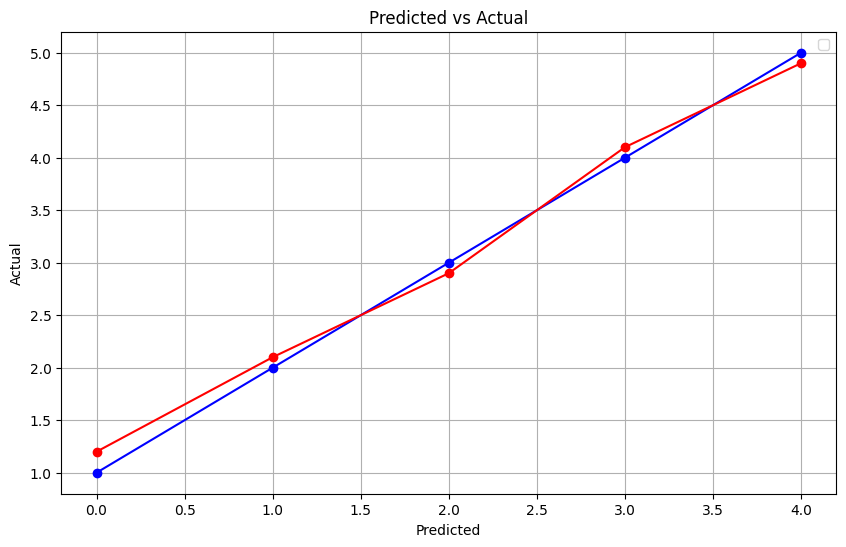

In [48]:
plt.figure(figsize=(10, 6))

plt.plot(predicted_values, marker='o', linestyle='-', color='blue', label="Predicted")
plt.plot(actual_values, marker='o', linestyle='-', color='red', label="Actual")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Predicted vs Actual")

# Add a legend
plt.legend([x, y], ["Predicted", "Actual"])

# Display the plot
plt.grid(True)
plt.show()

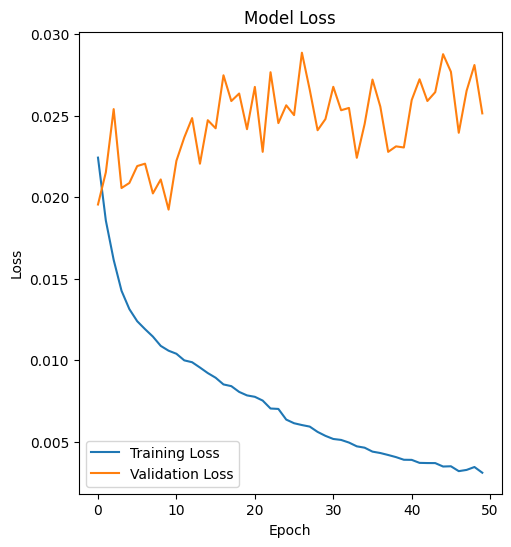

In [30]:
# Visualize results
plt.figure(figsize=(12, 6))

# Training history
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()